In [1]:
from langchain_community.llms import Bedrock
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import BedrockEmbeddings
from langchain.chains import RetrievalQA
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState

In [2]:
# 1. Load and index PDF
loader = PyPDFLoader("bns_v2.pdf")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, 
                                          chunk_overlap=200,
                                          separators=["\n\n", "\n", ".", " ", ""])
chunks = splitter.split_documents(docs)

In [108]:
# FILE_PATH = "https://arxiv.org/pdf/2408.09869"

In [109]:
# loader = PyPDFLoader("https://arxiv.org/pdf/2408.09869")
# docs1 = loader.load()
# splitter1 = RecursiveCharacterTextSplitter(chunk_size=1000, 
#                                           chunk_overlap=200,
#                                           separators=["\n\n", "\n", ".", " ", ""])
# chunks1 = splitter1.split_documents(docs1)

In [4]:
chunks

[Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20251020151201', 'source': 'bns_v2.pdf', 'total_pages': 20, 'page': 0, 'page_label': '1'}, page_content='THE BHARA TIYA NY AYA SANHITA, 2023\nNO. 45 OF 2023\n[25th December ,2023.]\nAn Act to consolidate and amend the provisions relating to offences and for\nmatters connected therewithor incidental thereto.\nBE it enacted by Parliament in the Seventy-fourth Year of the Republic of India as\nfollows:––\nCHAPTERI\nPRELIMINARY\n1.(1) This Act may be called the Bharatiya Nyaya Sanhita, 2023.\n(2) It shall come into force on such date as the Central Government may , bynotification\nin the Official Gazette, appoint, and different dates maybe appointed for different provisions\nof this Sanhita.\nShort title,\ncommencement\nand\napplication.\nvlk/kkj.k\nEXTRAORDINARY\nHkkx II — [k.M 1\nPART II — Section 1\nizkf/kdkj ls izdkf\'kr\nPUBLISHED BY AUTHORITY\nlañ 53] ubZ fnYyh] lkseokj] fnlEcj 25] 2023@ ikS"k 4] 1945 ¼

In [5]:
len(chunks)

95

In [6]:
chunks[15]

Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20251020151201', 'source': 'bns_v2.pdf', 'total_pages': 20, 'page': 4, 'page_label': '5'}, page_content='of any property, or to execute any judicial process, or to administer any oath, or\nto interpret, or to preserve order in the Court, and every person specially\nauthorised by a Court to perform any of such duties;\n(d) every assessor or member of a panchayat assisting a Court or public\nservant;\n(e) every arbitrator or other person to whom any cause or matter has been\nreferred for decision or report by any Court, or by any other competent public\nauthority;\n(f) every person who holds any office by virtue of which he is empowered\nto place or keep any person in confinement;\n(g) every officer of the Government whose duty it is, as such officer, to\nprevent offences, to give information of offences, to bring offenders to justice,\nor to protect the public health, safety or convenience;\n(h) every offic

In [8]:
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings

embedding_model = BedrockEmbeddings(model_id="cohere.embed-english-v3")
# from langchain_community.embeddings import SentenceTransformerEmbeddings
# embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(chunks, embedding_model)

In [9]:
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)
llm.invoke("Hi")


AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': 'a720dc36-bcbe-43c1-b17a-73beca4f9703', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Sun, 26 Oct 2025 07:36:29 GMT', 'content-type': 'application/json', 'content-length': '232', 'connection': 'keep-alive', 'x-amzn-requestid': 'a720dc36-bcbe-43c1-b17a-73beca4f9703'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [359]}, 'model_name': 'cohere.command-r-plus-v1:0'}, id='run--ee76e49e-abef-4b33-a276-87fe071cf9de-0', usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

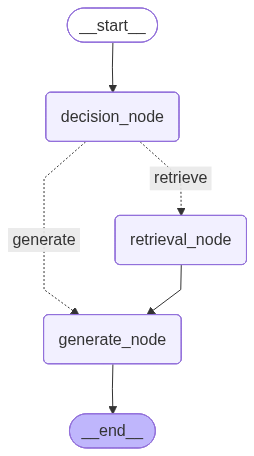

In [10]:
from typing import List, Literal, Optional
from typing_extensions import TypedDict
import os
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState


# ----------------------------
# Tool for context retrieval
# ----------------------------
@tool
def retrieve_context(query: str):
    """Search for relevant documents and return a text context."""
    retriever = vectorstore.as_retriever(k=4)
    results = retriever.invoke(query)

    # Return a compact text context
    return "\n\n".join([d.page_content for d in results])

# ----------------------------
# LLMs
# ----------------------------
# Model bound to no tools – we will use it for decision + answering.
router_llm = llm
answer_llm =llm

# ----------------------------
# State schema
# ----------------------------
class AgentState(MessagesState):
    """
    Extend MessagesState with our extra fields.
    MessagesState provides:
        messages: List[BaseMessage]
    """
    documents: List[str]           # context chunks or text slices
    answer: str                    # final answer
    needs_retrieval: bool          # route flag

# ----------------------------
# Helper: get user question
# ----------------------------
def get_last_user_message(messages: List[BaseMessage]) -> str:
    # Find last HumanMessage content (fallback to last message's content)
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return str(msg.content)
    return str(messages[-1].content) if messages else ""

# ----------------------------
# Node: decision
# ----------------------------
def decision_node(state: AgentState) -> AgentState:
    """
    Decide whether to 'retrieve' or 'generate' based on the last user message.
    Uses a small LLM classifier – no tool calls here.
    """
    question = get_last_user_message(state["messages"])
    prompt = f"""You are a router.You route the query based on whether it is related to Bharatiya nyay 
    sanhita or Indian Penal Code.Decide if answering the user's query needs retrieval from external docs.
    Reply with exactly one token: retrieve or generate.
    
    If the query asks for definitions, lists, explanations referencing documentation/tutorials,
    or might benefit from additional factual grounding, choose: retrieve.Otherwise, choose: generate.
    Query:{question} """
    resp = router_llm.invoke(prompt)
    decision = resp.content.strip().lower()
    needs_retrieval = (decision == "retrieve")

    return {
        **state,
        "needs_retrieval": needs_retrieval
    }

# ----------------------------
# Node: retrieve
# ----------------------------
def retrieval_node(state: AgentState) -> AgentState:
    """
    Calls the @tool directly, stores context into state["documents"].
    """
    question = get_last_user_message(state["messages"])
    # Since @tool creates a StructuredTool, call with dict input:
    context_text = retrieve_context.invoke({"query": question})
    docs_list = [context_text] if context_text else []

    # Keep messages unchanged here; just enrich the state
    return {
        **state,
        "documents": docs_list
    }

# ----------------------------
# Node: generate
# ----------------------------
def generate_node(state: AgentState) -> AgentState:
    """
    Generates the final answer, using retrieved context if present.
    Also appends an AIMessage so your MessagesState stays in sync.
    """
    question = get_last_user_message(state["messages"])
    docs = state.get("documents", [])
    if docs:
        context = "\n\n".join(docs)
        prompt = f"""Use the context to answer concisely and correctly.
        Context: {context}
        Question: {question}
        Answer:"""
    else:
        prompt = f"Answer the following question concisely and correctly:\n\n{question}"

    resp = answer_llm.invoke(prompt)
    answer = resp.content

    # Append the answer as an AIMessage so printing last message still works
    new_messages = state["messages"] + [AIMessage(content=answer)]

    return {
        **state,
        "messages": new_messages,
        "answer": answer
    }

# ----------------------------
# conditional_logic function for edges
# ----------------------------
def conditional_logic(state: AgentState) -> Literal["retrieve", "generate"]:
    return "retrieve" if state.get("needs_retrieval", False) else "generate"

# ----------------------------
# Build the graph
# ----------------------------
workflow = StateGraph(AgentState)

workflow.add_node("decision_node", decision_node)
workflow.add_node("retrieval_node", retrieval_node)
workflow.add_node("generate_node", generate_node)

workflow.set_entry_point("decision_node")

workflow.add_conditional_edges(
    "decision_node",
    conditional_logic,
    {
        "retrieve": "retrieval_node",
        "generate": "generate_node",
    }
)

# After retrieval, go to generate, then END
workflow.add_edge("retrieval_node", "generate_node")
workflow.add_edge("generate_node", END)

# Configure memory to persist the conversation (thread-aware)
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

workflow.compile(checkpointer=checkpointer)

In [11]:
# ----------------------------
final_state = app.invoke(
    {"messages": [HumanMessage(content="What is an act and counterfiet according to Bharatiya Nyay Sanhita? ")], 
     "documents": [], "answer": "", "needs_retrieval": False},
    config={"configurable": {"thread_id": 11}}
)

# You can read either the final message...
from rich import print
print(final_state["messages"][-1].content)

According to the Bharatiya Nyaya Sanhita, an "act" denotes a series of acts as well as a single act. A person is 
said to "counterfeit" when they cause one thing to resemble another with the intention to deceive.

In [12]:
print(final_state)

{
    'messages': [
        HumanMessage(
            content='What is an act and counterfiet according to Bharatiya Nyay Sanhita? ',
            additional_kwargs={},
            response_metadata={},
            id='4f35f9ac-c5de-4bda-96ed-953a058af442'
        ),
        AIMessage(
            content='According to the Bharatiya Nyaya Sanhita, an "act" denotes a series of acts as well as a 
single act. A person is said to "counterfeit" when they cause one thing to resemble another with the intention to 
deceive.',
            additional_kwargs={},
            response_metadata={},
            id='b118b111-a723-4e20-9aa7-d842187556e1'
        )
    ],
    'documents': [
        'Explanation.—In this section, the word “offence” includes every act committed outside\nIndia which, if 
committed in India, would be punishable under this Sanhita.\nIllustration.\nA, who is a citizen of India, commits a
murder in any place without and beyond India.\nHe can be tried and convicted of murder in any place in India in 
which he may be found.\n(6) Nothing in this Sanhita shall affect the provisions of any Act for punishing 
mutiny\nand desertion of officers, soldiers, sailors or airmen in the service of the Government of India\nor the 
provisions of any special or local law.\n2.In this Sanhita, unless the context otherwise requires,––\n(1) “act” 
denotes as well a series of acts as a single act;\n(2) “animal” means any living creature, other than a human 
being;\n(3) “child” means any person below the age of eighteen years;\n(4) “counterfeit”.––A person is said to 
“counterfeit” who causes one thing to\nresemble another thing, intending by means of that resemblance to practise 
deception,\n\nTHE BHARA TIYA NY AYA SANHITA, 2023\nNO. 45 OF 2023\n[25th December ,2023.]\nAn Act to consolidate 
and amend the provisions relating to offences and for\nmatters connected therewithor incidental thereto.\nBE it 
enacted by Parliament in the Seventy-fourth Year of the Republic of India 
as\nfollows:––\nCHAPTERI\nPRELIMINARY\n1.(1) This Act may be called the Bharatiya Nyaya Sanhita, 2023.\n(2) It 
shall come into force on such date as the Central Government may , bynotification\nin the Official Gazette, 
appoint, and different dates maybe appointed for different provisions\nof this Sanhita.\nShort 
title,\ncommencement\nand\napplication.\nvlk/kkj.k\nEXTRAORDINARY\nHkkx II — [k.M 1\nPART II — Section 1\nizkf/kdkj
ls izdkf\'kr\nPUBLISHED BY AUTHORITY\nlañ 53] ubZ fnYyh] lkseokj] fnlEcj 25] 2023@ ikS"k 4] 1945 ¼\'kd½\nNo. 53] 
NEW DELHI, MONDAY, DECEMBER 25, 2023/PAUSHA 4, 1945 (SAKA)\nbl Hkkx esa fHkUu i`"B la[;k nh tkrh gS ftlls fd ;g vyx
ladyu ds :i esa j[kk tk ldsA\n\nto kill him, and not having been subject to the provocation, assists A in killing 
Z. Here,\nthough A and B are both engaged in causing Z’s death, B is guilty of murder, and A is guilty\nonly of 
culpable homicide.\nCHAPTERII\nOF PUNISHMENTS\n4.The punishments to which offenders are liable under the provisions
of this Sanhita\nare—\n(a) Death;\n(b) Imprisonment for life;\n(c) Imprisonment, which is of two descriptions, 
namely:—\n(1) Rigorous, that is, with hard labour;\n(2) Simple;\n(d) Forfeiture of property;\n(e) Fine;\n(f) 
Community Service.\n5.The appropriate Government may, without the consent of the offender, commute\nany punishment 
under this Sanhita to any other punishment in accordance with section 474\nof the Bharatiya Nagarik Suraksha 
Sanhita, 2023.\nExplanation.––For the purposes of this section the expression “appropriate\nGovernment” 
means,––\n(a) in cases where the sentence is a sentence of death or is for an offence\n\n(3) Every person shall be 
liable to punishment under this Sanhita and not otherwise for\nevery act or omission contrary to the provisions 
thereof, of which he shall be guilty within\nIndia.\n(4) Any person liable, by any law for the time being in force 
in India, to be tried for an\noffence committed beyond India shall be dealt with according to the p

In [79]:
# ----------------------------
final_state = app.invoke(
    {"messages": [HumanMessage(content="What is an act and counterfiet according to Bharatiya Nyay Sanhita? ")], 
     "documents": [], "answer": "", "needs_retrieval": False},
    config={"configurable": {"thread_id": 11}}
)

# You can read either the final message...
from rich import print
print(final_state["messages"][-1].content)

According to the Bharatiya Nyaya Sanhita, 2023:

* An "act" refers to any physical or mental movement, gesture, or omission.
* A "counterfeit" is not explicitly defined in this Act. However, based on general legal principles, it can be 
inferred that a counterfeit would refer to an act of counterfeiting currency, documents, or other items with the 
intention of deceiving others.

In [80]:
print(final_state)

{
    'messages': [
        HumanMessage(
            content='What is an act and counterfiet according to Bharatiya Nyay Sanhita? ',
            additional_kwargs={},
            response_metadata={},
            id='d6d6959f-e7d5-49cf-b051-6a56e150a6f5'
        ),
        AIMessage(
            content='According to the Bharatiya Nyaya Sanhita, 2023:\n\n* An "act" refers to any physical or mental
movement, gesture, or omission.\n* A "counterfeit" is not explicitly defined in this Act. However, based on general
legal principles, it can be inferred that a counterfeit would refer to an act of counterfeiting currency, 
documents, or other items with the intention of deceiving others.',
            additional_kwargs={},
            response_metadata={},
            id='0032b307-7e0b-4c94-ac19-b5fb1260c085'
        )
    ],
    'documents': [
        'THE BHARA TIYA NY AYA SANHITA, 2023\nNO. 45 OF 2023\n[25th December ,2023.]\nAn Act to consolidate and 
amend the provisions relating to offences and for\nmatters connected therewithor incidental thereto.\nBE it enacted
by Parliament in the Seventy-fourth Year of the Republic of India as\nfollows:––\nCHAPTERI\nPRELIMINARY\n1.(1) This
Act may be called the Bharatiya Nyaya Sanhita, 2023.\n(2) It shall come into force on such date as the Central 
Government may , bynotification\n\n(3) Every person shall be liable to punishment under this Sanhita and not 
otherwise for\nevery act or omission contrary to the provisions thereof, of which he shall be guilty 
within\nIndia.\n(4) Any person liable, by any law for the time being in force in India, to be tried for an\noffence
committed beyond India shall be dealt with according to the provisions of this\nSanhita for any act committed 
beyond India in the same manner as if such act had been\ncommitted within India.\n\n(b) commits any act which is 
prejudicial to the maintenance of harmony between\ndifferent religious, racial, language or regional groups or 
castes or communities, and\nwhich disturbs or is likely to disturb the public tranquillity; or\n(c) organises any 
exercise, movement, drill or other similar activity intending that\nthe participants in such activity shall use or 
be trained to use criminal force or violence\n\n(4) In every Part of this Sanhita, except where a contrary 
intention appears from the\ncontext, words which refer to acts done extend also to illegal omissions.\n(5) When a 
criminal act is done by several persons in furtherance of the common\nintention of all, each of such persons is 
liable for that act in the same manner as if it were done\nby him alone.\n(6) Whenever an act, which is criminal 
only by reason of its being done with a criminal'
    ],
    'answer': 'According to the Bharatiya Nyaya Sanhita, 2023:\n\n* An "act" refers to any physical or mental 
movement, gesture, or omission.\n* A "counterfeit" is not explicitly defined in this Act. However, based on general
legal principles, it can be inferred that a counterfeit would refer to an act of counterfeiting currency, 
documents, or other items with the intention of deceiving others.',
    'needs_retrieval': True
}

In [81]:
# ----------------------------
final_state = app.invoke(
    {"messages": [HumanMessage(content="Summarize the provisions for culpable homicide according to Bharatiya Nyay Sanhita? ")], 
     "documents": [], "answer": "", "needs_retrieval": False},
    config={"configurable": {"thread_id": 11}}
)

# You can read either the final message...
from rich import print
print(final_state["messages"][-1].content)

There are no specific provisions mentioned for culpable homicide in the given context. However, it is mentioned 
that sections 307 and 311 of the Bharatiya Nyay Sanhita deal with offenses related to culpable homicide.

In [82]:
print(final_state)

{
    'messages': [
        HumanMessage(
            content='What is an act and counterfiet according to Bharatiya Nyay Sanhita? ',
            additional_kwargs={},
            response_metadata={},
            id='d6d6959f-e7d5-49cf-b051-6a56e150a6f5'
        ),
        AIMessage(
            content='According to the Bharatiya Nyaya Sanhita, 2023:\n\n* An "act" refers to any physical or mental
movement, gesture, or omission.\n* A "counterfeit" is not explicitly defined in this Act. However, based on general
legal principles, it can be inferred that a counterfeit would refer to an act of counterfeiting currency, 
documents, or other items with the intention of deceiving others.',
            additional_kwargs={},
            response_metadata={},
            id='0032b307-7e0b-4c94-ac19-b5fb1260c085'
        ),
        HumanMessage(
            content='Summarize the provisions for culpable homicide according to Bharatiya Nyay Sanhita? ',
            additional_kwargs={},
            response_metadata={},
            id='c3e20306-c4c9-4fb6-acd1-0e1e3a047409'
        ),
        AIMessage(
            content='There are no specific provisions mentioned for culpable homicide in the given context. 
However, it is mentioned that sections 307 and 311 of the Bharatiya Nyay Sanhita deal with offenses related to 
culpable homicide.',
            additional_kwargs={},
            response_metadata={},
            id='91d68d5d-e7a6-435e-8708-c85e3151bae1'
        )
    ],
    'documents': [
        '(3) Every person shall be liable to punishment under this Sanhita and not otherwise for\nevery act or 
omission contrary to the provisions thereof, of which he shall be guilty within\nIndia.\n(4) Any person liable, by 
any law for the time being in force in India, to be tried for an\noffence committed beyond India shall be dealt 
with according to the provisions of this\nSanhita for any act committed beyond India in the same manner as if such 
act had been\ncommitted within India.\n\nsections, namely, 103, 105, 307, sub-sections (2), (3) and (4) of section 
309, sub-sections (2),\n(3), (4) and (5) of section 310, 311, 312, clauses (f) and (g) of section 326, sub-sections
(4),\n(6), (7) and (8) of section 331, clauses (a) and (b) of section 332 and every such act shall,\nfor the 
purposes of this section, be deemed to be punishable as if the accused person had\nbeen guilty of it in 
India.\nDishonestly\nmaking false\nclaim in\nCourt.\nFraudulently\nobtaining\ndecree for sum\nnot 
due.\n\nprostitution,\netc.\nCulpable\nhomicide.\nSec. 1] THE GAZETTE OF INDIA EXTRAORDINAR Y 
31_________________________________________________________________________________________________________________
___________________________________________________________________________________________________________________
___________________________________________________________________________________________________________________
______________\n\nIndia which, if committed in India, would be punishable under this Sanhita.\nIllustration.\nA, 
who is a citizen of India, commits a murder in any place without and beyond India.\nHe can be tried and convicted 
of murder in any place in India in which he may be found.\n(6) Nothing in this Sanhita shall affect the provisions 
of any Act for punishing mutiny\nand desertion of officers, soldiers, sailors or airmen in the service of the 
Government of India\nor the provisions of any special or local law.'
    ],
    'answer': 'There are no specific provisions mentioned for culpable homicide in the given context. However, it 
is mentioned that sections 307 and 311 of the Bharatiya Nyay Sanhita deal with offenses related to culpable 
homicide.',
    'needs_retrieval': True
}

In [62]:
# “Which sections define punishment for homicide?”
# “What does Section 101 state?”
# “Summarize the provisions for culpable homicide.”